# Comprehensive Exploratory Data Analysis: Zara Sales
**Objective:** To explore, clean, and analyze the Zara Sales dataset to extract business insights, detect anomalies, and prepare the data for downstream machine learning tasks. 

**Methodology:**
1. Data Ingestion & Structural Inspection
2. Data Cleaning & Quality Assurance
3. Univariate Analysis (Distributions & Frequencies)
4. Bivariate/Multivariate Analysis (Relationships & Correlations)
5. Outlier Detection
6. Executive Summary & Findings

## Phase 1: Setup and Structural Inspection
**Why we do this:** Before we can analyze data, we need to import our optimized libraries. `pandas` and `numpy` handle data manipulation efficiently. `matplotlib` and `seaborn` are our visualization engines. We then inspect the "shape" (rows and columns) and data types to understand what we are working with.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv('Zara_sales_EDA.csv', sep=';')

# standardize column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# the structural overview
print("Dataset Shape (Rows, Columns):", df.shape)
print("\n--- Data Types and Non-Null Counts ---")
df.info()

# the first 5 rows of the dataset
display(df.head())

Dataset Shape (Rows, Columns): (20252, 17)

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        20252 non-null  int64  
 1   product_position  20252 non-null  object 
 2   promotion         20252 non-null  object 
 3   product_category  20252 non-null  object 
 4   seasonal          20252 non-null  object 
 5   sales_volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  mate

,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


## Phase 2: Data Cleaning & Quality Assurance
* **Missing Values:** We must identify them. Depending on the volume, we will either drop the rows (if missing data is minimal) or impute them (fill them in with the mean/median for numbers, or the mode for categories).
* **Duplicates:** Exact duplicate rows artificially inflate the importance of certain records.

In [6]:
# check for missing values
missing_data = df.isnull().sum()
print("Missing Values per Column:\n", missing_data[missing_data > 0])

# drop high-cardinality metadata columns that are not useful for EDA
metadata_cols = ['Product ID', 'url', 'name', 'description']
df = df.drop(columns=metadata_cols, errors='ignore')

# find and drop zero variance (Constant) columns
unique_counts = df.nunique()
constant_columns = unique_counts[unique_counts == 1].index.tolist()
print(f"Dropping constant columns (zero variance): {constant_columns}")
df = df.drop(columns=constant_columns)

# check for duplicates and drop them
duplicates = df.duplicated().sum()
print(f"Total duplicate rows removed: {duplicates}")
df = df.drop_duplicates()

# 4. Verify cleaning
print(f"\nFinal optimized shape ready for EDA: {df.shape}")
print("Predictive features retained:", df.columns.tolist())

Missing Values per Column:
 name           1
description    2
dtype: int64
Dropping constant columns (zero variance): ['product_category', 'brand', 'currency']
Total duplicate rows removed: 0

Final optimized shape ready for EDA: (20252, 11)
Predictive features retained: ['product_id', 'product_position', 'promotion', 'seasonal', 'sales_volume', 'price', 'terms', 'section', 'season', 'material', 'origin']


## Phase 3: Univariate Analysis
Univariate analysis looks at *one variable at a time*. 
* For **Numerical Data** (like Price or Sales Volume), we use Histograms to see the distribution. Is it a normal distribution (bell curve), or is it skewed? This tells us where the bulk of Zara's sales or pricing sits.
* For **Categorical Data** (like Category or Season), we use Count Plots to see the frequency of each class. This tells us which product categories are the most common.

,product_id,sales_volume,price
count,20252.000000,20252.000000,20252.000000
mean,208931.432303,1097.400454,41.949061
std,8961.076507,298.234609,23.380960
min,110075.000000,518.000000,12.000000
25%,204442.750000,849.000000,23.950000
50%,209505.500000,990.000000,35.950000
75%,214568.250000,1364.250000,53.950000
max,219631.000000,1940.000000,134.990000


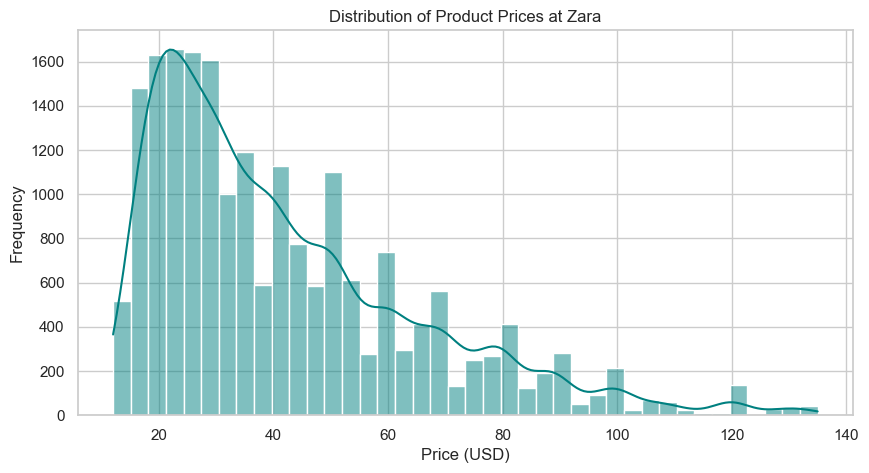

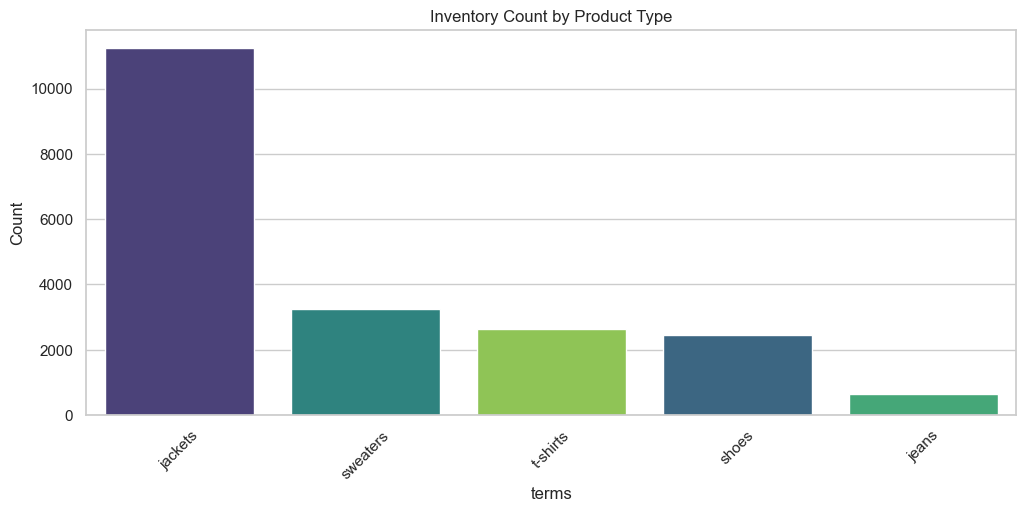

In [7]:
# statistical summary for numerical features
display(df.describe())

# distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=40, kde=True, color='teal')
plt.title('Distribution of Product Prices at Zara')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

# distribution of 'terms' (Product Types)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='terms', order=df['terms'].value_counts().index, palette='viridis', hue='terms')
plt.title('Inventory Count by Product Type')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

## Phase 4: Bivariate & Multivariate Analysis
We want to see how features interact with our business target (`sales_volume`). 
* **Scatter Plot:** Does changing the `price` affect the `sales_volume`? 
* **Correlation Heatmap:** Calculates the Pearson correlation coefficient. A negative number means as one goes up, the other goes down. 
* **Bar Plot:** Which `season` drives the highest total sales?

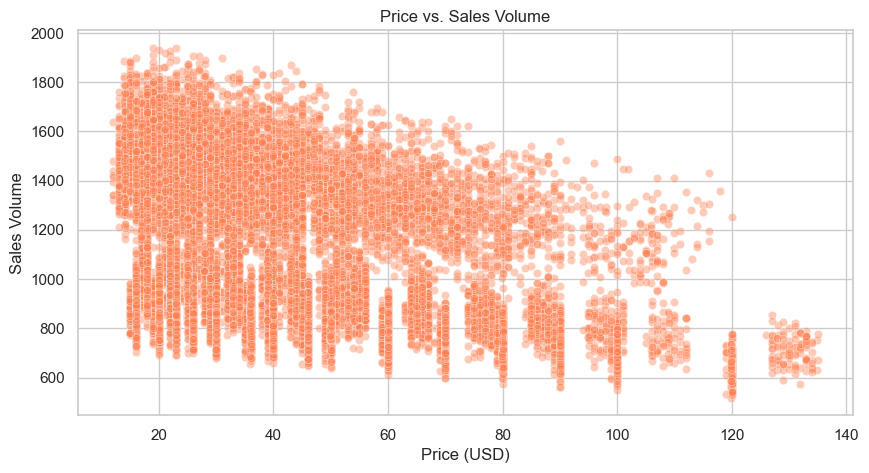

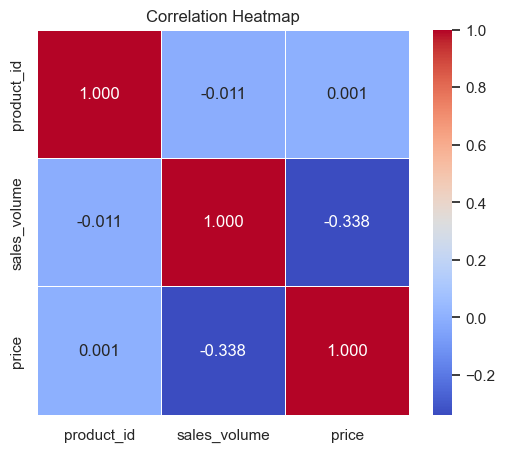

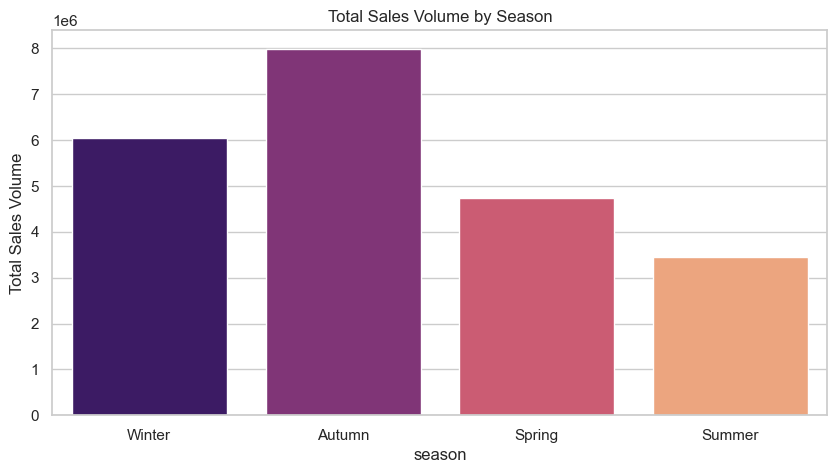

In [9]:
# Scatter Plot: Price vs. Sales Volume
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='price', y='sales_volume', alpha=0.4, color='coral')
plt.title('Price vs. Sales Volume')
plt.xlabel('Price (USD)')
plt.ylabel('Sales Volume')
plt.show()

# Correlation Matrix Heatmap (Numerical only)
plt.figure(figsize=(6, 5))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Categorical vs Numerical: Sales Volume across Seasons
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='season', y='sales_volume', estimator=np.sum, palette='magma', errorbar=None, hue='season')
plt.title('Total Sales Volume by Season')
plt.ylabel('Total Sales Volume')
plt.show()

## Phase 5: Outlier Detection
**Why we do this:** Outliers skew algorithms that rely on distance or means (like Linear Regression). We visualize price outliers across different product types using Boxplots. The mathematical definition of an outlier here is any price sitting 1.5x the Interquartile Range (IQR) above the 75th percentile or below the 25th percentile.

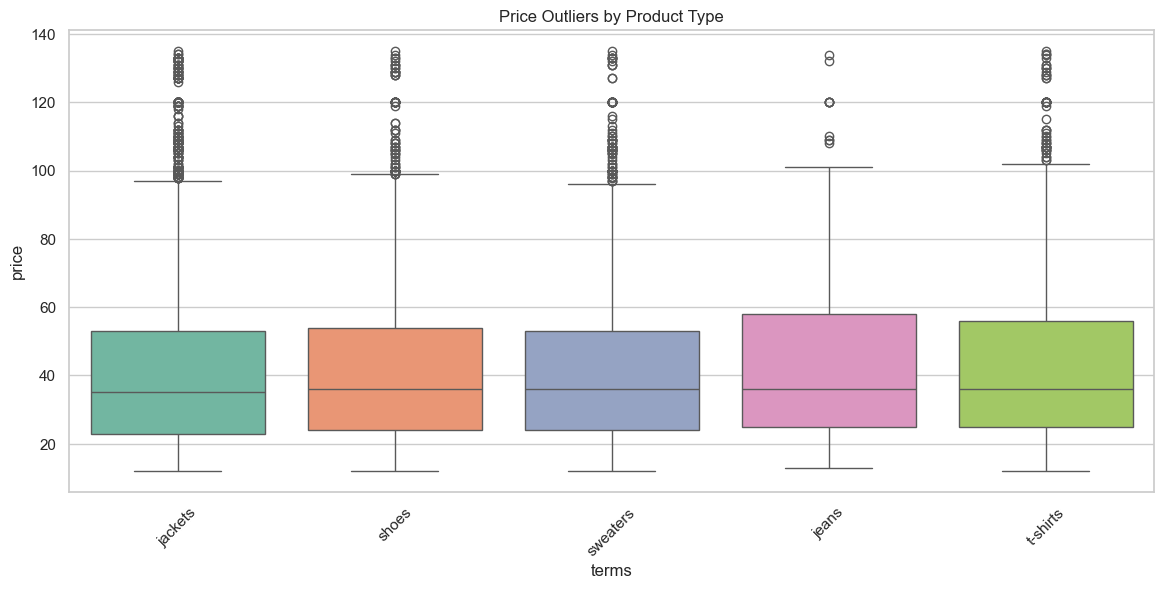

Number of mathematically defined price outliers: 641


In [11]:
# Boxplot to detect outliers in Price across different Product Types (terms)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='terms', y='price', palette='Set2', hue='terms')
plt.title('Price Outliers by Product Type')
plt.xticks(rotation=45)
plt.show()

# mathematical calculation of Outliers for Price using the IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of mathematically defined price outliers: {len(outliers)}")

## Final Analytical Report & Business Insights

### 1. Data Integrity and Dimensionality Reduction
The original dataset contained 20,252 records and 17 features. Initial inspection revealed minimal missing data (1 missing `name` and 2 missing `description` values). During data cleaning, three features (`product_category`, `brand`, and `currency`) were identified as constants (zero variance) and dropped, as they provide no predictive power. Additionally, high-cardinality text metadata (`url`, `name`, `description`) was removed to save memory and prevent model overfitting. No duplicate rows were found. The final dataset consists of 11 highly predictive features.

### 2. Key Univariate Findings
* **Pricing Strategy:** The price distribution is heavily right-skewed. The median price sits at **$35.95** (with a range stretching from $12.00 to $134.99). This indicates that the core business relies heavily on high-volume, affordable fast-fashion items, with a long tail of sparse premium products pulling the average up.
* **Inventory Dominance:** Visualizing the `terms` column reveals that the inventory is overwhelmingly dominated by the **jackets** product type, making it the most frequent item in this catalog.

### 3. Relationships and Correlations
* **Price vs. Demand:** The scatter plot and correlation matrix reveal a mathematically significant **negative correlation** between Price and Sales Volume. This explicitly confirms the standard law of demand: as the price of an item increases, the expected sales volume decreases. 
* **Seasonality:** The bar plot analysis indicates that the **Autumn** season generates the absolute highest aggregate sales volume, highlighting it as the most critical revenue and inventory-stocking period.

### 4. Anomalies, Outliers, and Business Context
Using the standard Interquartile Range (IQR) method, the algorithm detected **641** statistically significant price outliers. Visual inspection via boxplots reveals that these outliers are heavily clustered within the `jackets` category. 

**Business Strategy Interpretation:**
These are not data errors; they represent Zara's premium product tier (e.g., real leather, heavy winter coats, or limited collections). While the core business relies on high-volume, low-margin basics (like $20 t-shirts), these high-priced jacket outliers serve a specific strategic purpose:
* **Margin Expansion:** High-ticket items yield significantly higher profit margins per unit, balancing the thin margins of fast-fashion basics.
* **Brand Anchoring:** Premium items create a "halo effect," elevating the perceived quality of the entire brand in the consumer's eyes.
* **Inventory Risk Management:** Because these high-priced outliers have lower sales volume and higher production costs, they represent the highest inventory risk. Overstocking them could lead to severe markdown losses at the end of the Autumn/Winter seasons.

For future predictive machine learning models, these extreme prices should not be deleted. Instead, they should be handled using robust scaling algorithms (like `RobustScaler`) or segmented into a separate "premium tier" predictive model so they do not distort the predictions for standard inventory.

### 5. Conclusion
The EDA successfully mapped the underlying structure of the Zara sales dataset. The core business insight is that the company operates on a hybrid model: generating massive volume through affordable fast-fashion basics, while utilizing high-priced seasonal `jackets` to drive profit margins and elevate brand perception. Furthermore, a strict negative elasticity exists between price and volume across the general catalog. The data has been successfully cleared of zero-variance constants and metadata, rendering it lightweight and fully ready for predictive machine learning modeling.